In [1]:

!git clone -b EMT https://github.com/pop756/Quantum_KAN.git
%cd Quantum_KAN
!pip install -r requirements.txt

Cloning into 'Quantum_KAN'...
remote: Enumerating objects: 942, done.
remote: Counting objects: 100% (105/105), done.
remote: Compressing objects: 100% (90/90), done.
remote: Total 942 (delta 42), reused 50 (delta 14), pack-reused 837
Receiving objects: 100% (942/942), 28.68 MiB | 11.74 MiB/s, done.
Resolving deltas: 100% (160/160), done.
/content/Quantum_KAN
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.2/69.2 kB 5.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 36.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 24.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 29.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 12.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.9/249.9 kB 12.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
!pip install qiskit_experiments

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 727.5/727.5 kB 10.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 6.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 6.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.9/105.9 kB 7.4 MB/s eta 0:00:00


In [3]:
# Configure JAX
import jax
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "cpu")

In [4]:
import numpy as np

dim = 3

v0 = 4.86e9
anharm0 = -0.5e9
r0 = 0.22e9

v1 = (4.97)*1e9
anharm1 = -0.5e9
r1 = 0.26e9

J = 0.002e9

a = np.diag(np.sqrt(np.arange(1, dim)), 1)
adag = np.diag(np.sqrt(np.arange(1, dim)), -1)
N = np.diag(np.arange(dim))

ident = np.eye(dim, dtype=complex)
full_ident = np.eye(dim**2, dtype=complex)

N0 = np.kron(ident, N)
N1 = np.kron(N, ident)

a0 = np.kron(ident, a)
a1 = np.kron(a, ident)

a0dag = np.kron(ident, adag)
a1dag = np.kron(adag, ident)


static_ham0 = 2 * np.pi * v0 * N0 + np.pi * anharm0 * N0 * (N0 - full_ident)
static_ham1 = 2 * np.pi * v1 * N1 + np.pi * anharm1 * N1 * (N1 - full_ident)

static_ham_full = static_ham0 + static_ham1 + 2 * np.pi * J * ((a0 + a0dag) @ (a1 + a1dag))

drive_op0 = 2 * np.pi * r0 * (a0 + a0dag)
drive_op1 = 2 * np.pi * r1 * (a1 + a1dag)

In [5]:
from qiskit_dynamics import Solver

# build solver
dt = 1/4.5e9

solver = Solver(
    static_hamiltonian=static_ham_full,
    hamiltonian_operators=[drive_op0, drive_op1, drive_op0, drive_op1],
    rotating_frame=static_ham_full,
    hamiltonian_channels=["d0", "d1", "u0", "u1"],
    channel_carrier_freqs={"d0": v0, "d1": v1, "u0": v1, "u1": v0},
    dt=dt,
    array_library="jax",
)

In [6]:
from qiskit_dynamics import DynamicsBackend

# Consistent solver option to use throughout notebook
solver_options = {"method": "jax_odeint", "atol": 1e-6, "rtol": 1e-8, "hmax": dt}

backend = DynamicsBackend(
    solver=solver,
    subsystem_dims=[dim, dim], # for computing measurement data
    solver_options=solver_options, # to be used every time run is called
)

In [7]:
%%time

from qiskit import pulse

sigma = 128
num_samples = 256

schedules = []

for amp in np.linspace(0., 1., 10):
    gauss = pulse.library.Gaussian(
        num_samples, amp, sigma, name="Parametric Gauss"
    )

    with pulse.build() as schedule:
        with pulse.align_sequential():
            pulse.play(gauss, pulse.DriveChannel(0))
            pulse.shift_phase(0.5, pulse.DriveChannel(0))
            pulse.shift_frequency(0.1, pulse.DriveChannel(0))
            pulse.play(gauss, pulse.DriveChannel(0))
            pulse.acquire(duration=1, qubit_or_channel=0, register=pulse.MemorySlot(0))

    schedules.append(schedule)

job = backend.run(schedules, shots=100)
result = job.result()

CPU times: user 3.7 s, sys: 263 ms, total: 3.96 s
Wall time: 9.34 s


In [8]:
from qiskit.circuit.library import XGate, SXGate, RZGate, CXGate
from qiskit.circuit import Parameter
from qiskit.providers.backend import QubitProperties
from qiskit.circuit.library import HGate
from qiskit.transpiler import InstructionProperties

target = backend.target

# qubit properties
target.qubit_properties = [QubitProperties(frequency=v0), QubitProperties(frequency=v1)]

# add instructions
target.add_instruction(XGate(), properties={(0,): None, (1,): None})
target.add_instruction(SXGate(), properties={(0,): None, (1,): None})

target.add_instruction(CXGate(), properties={(0, 1): None, (1, 0): None})

# Add RZ instruction as phase shift for drag cal
phi = Parameter("phi")
with pulse.build() as rz0:
    pulse.shift_phase(phi, pulse.DriveChannel(0))
    pulse.shift_phase(phi, pulse.ControlChannel(1))

with pulse.build() as rz1:
    pulse.shift_phase(phi, pulse.DriveChannel(1))
    pulse.shift_phase(phi, pulse.ControlChannel(0))

target.add_instruction(
    RZGate(phi),
    {(0,): InstructionProperties(calibration=rz0), (1,): InstructionProperties(calibration=rz1)}
)

In [9]:
import pandas as pd
from qiskit_experiments.calibration_management.calibrations import Calibrations
from qiskit_experiments.calibration_management.basis_gate_library import FixedFrequencyTransmon

cals = Calibrations(libraries=[FixedFrequencyTransmon(basis_gates=['x', 'sx'])])

pd.DataFrame(**cals.parameters_table(qubit_list=[0,1, ()]))

,parameter,qubits,schedule,value,group,valid,date_time,exp_id
0,duration,(),sx,160.00,default,True,2024-07-12 12:06:40.940473+0000,None
1,amp,(),sx,0.25,default,True,2024-07-12 12:06:40.947661+0000,None
2,duration,(),x,160.00,default,True,2024-07-12 12:06:40.940387+0000,None
3,β,(),sx,0.00,default,True,2024-07-12 12:06:40.940491+0000,None
4,amp,(),x,0.50,default,True,2024-07-12 12:06:40.940431+0000,None
5,β,(),x,0.00,default,True,2024-07-12 12:06:40.940288+0000,None
6,angle,(),sx,0.00,default,True,2024-07-12 12:06:40.947743+0000,None
7,σ,(),sx,40.00,default,True,2024-07-12 12:06:40.940452+0000,None
8,angle,(),x,0.00,default,True,2024-07-12 12:06:40.940410+0000,None
9,σ,(),x,40.00,default,True,2024-07-12 12:06:40.940362+0000,None


In [10]:
from qiskit_experiments.library.calibration import RoughXSXAmplitudeCal

# rabi experiments for qubit 0
rabi0 = RoughXSXAmplitudeCal([0], cals, backend=backend, amplitudes=np.linspace(-0.2, 0.2, 27))

# rabi experiments for qubit 1
rabi1 = RoughXSXAmplitudeCal([1], cals, backend=backend, amplitudes=np.linspace(-0.2, 0.2, 27))

In [11]:
%%time
rabi0_data = rabi0.run().block_for_results()
rabi1_data = rabi1.run().block_for_results()

CPU times: user 13.2 s, sys: 511 ms, total: 13.7 s
Wall time: 26.2 s


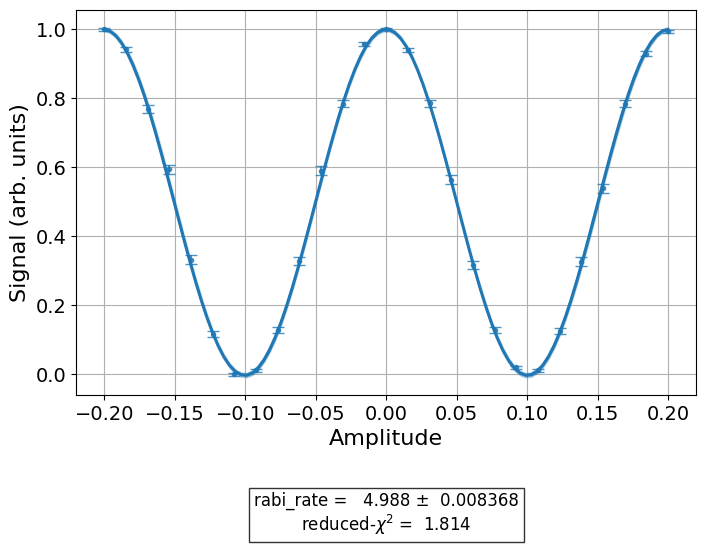

In [12]:
rabi1_data.figure(0)

In [13]:
# set the control channel map
backend.set_options(control_channel_map={(0, 1): 0, (1, 0): 1})

In [14]:
pd.DataFrame(**cals.parameters_table(qubit_list=[0, ()], parameters="amp"))

,parameter,qubits,schedule,value,group,valid,date_time,exp_id
0,amp,(),sx,0.2500,default,True,2024-07-12 12:06:40.947661+0000,None
1,amp,"(0,)",x,0.1188,default,True,2024-07-12 12:06:52.573101+0000,4bdfb7c1-6644-4dec-b4a6-77cbdfd6491a
2,amp,(),x,0.5000,default,True,2024-07-12 12:06:40.940431+0000,None
3,amp,"(0,)",sx,0.0594,default,True,2024-07-12 12:06:52.573101+0000,4bdfb7c1-6644-4dec-b4a6-77cbdfd6491a


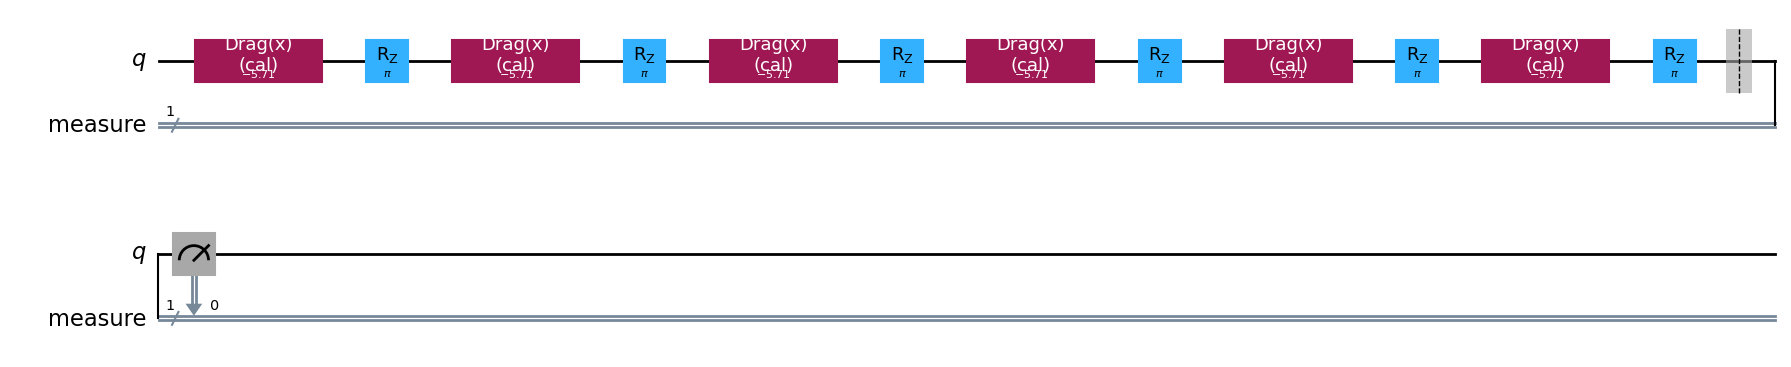

In [15]:
from qiskit_experiments.library.calibration import RoughDragCal

cal_drag0 = RoughDragCal([0], cals, backend=backend, betas=np.linspace(-20, 20, 15))
cal_drag1 = RoughDragCal([1], cals, backend=backend, betas=np.linspace(-20, 20, 15))

cal_drag0.set_experiment_options(reps=[3, 5, 7])
cal_drag1.set_experiment_options(reps=[3, 5, 7])

cal_drag0.circuits()[5].draw(output="mpl")

In [16]:
%%time
drag0_data = cal_drag0.run().block_for_results()
drag1_data = cal_drag1.run().block_for_results()

CPU times: user 47.5 s, sys: 8.76 s, total: 56.3 s
Wall time: 47.6 s


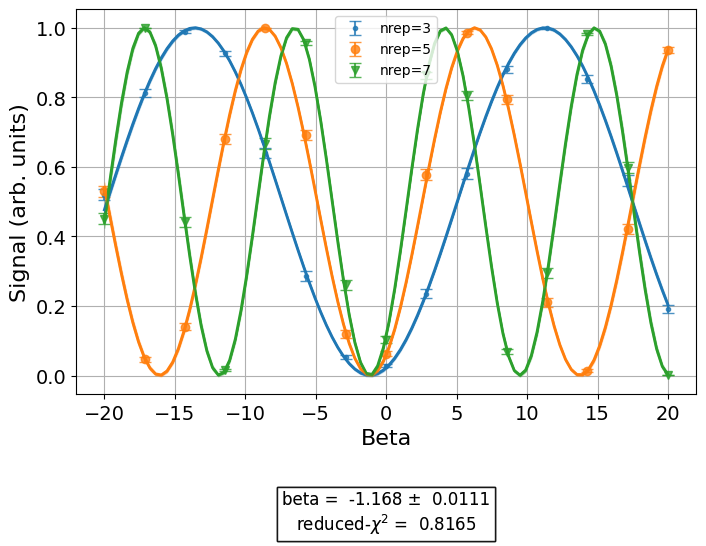

In [17]:
drag1_data.figure(0)

In [18]:
pd.DataFrame(**cals.parameters_table(qubit_list=[1, ()], parameters="amp"))

,parameter,qubits,schedule,value,group,valid,date_time,exp_id
0,amp,(),sx,0.250000,default,True,2024-07-12 12:06:40.947661+0000,None
1,amp,"(1,)",x,0.100250,default,True,2024-07-12 12:07:04.347544+0000,ca2f4dea-307d-49b8-89cb-bd72f048e8b6
2,amp,(),x,0.500000,default,True,2024-07-12 12:06:40.940431+0000,None
3,amp,"(1,)",sx,0.050125,default,True,2024-07-12 12:07:04.347544+0000,ca2f4dea-307d-49b8-89cb-bd72f048e8b6


In [19]:
backend.target.update_from_instruction_schedule_map(cals.get_inst_map())

In [20]:
# set the control channel map
backend.set_options(control_channel_map={(0, 1): 0, (1, 0): 1})

In [120]:
from qiskit_experiments.library import CrossResonanceHamiltonian
from qiskit import circuit
class CrossResonanceHamiltonian_angle(CrossResonanceHamiltonian):
    r"""Echoed cross resonance Hamiltonian tomography experiment.

    # section: overview

        This is a variant of :class:`CrossResonanceHamiltonian`
        for which the experiment framework is identical but the
        cross resonance operation is realized as an echoed sequence
        to remove unwanted single qubit rotations. The cross resonance
        circuit looks like:

        .. parsed-literal::

                 ┌────────────────────┐  ┌───┐  ┌────────────────────┐
            q_0: ┤0                   ├──┤ X ├──┤0                   ├──────────
                 │  cr_tone(duration) │┌─┴───┴─┐│  cr_tone(duration) │┌────────┐
            q_1: ┤1                   ├┤ Rz(π) ├┤1                   ├┤ Rz(-π) ├
                 └────────────────────┘└───────┘└────────────────────┘└────────┘

        Here two ``cr_tone`` are applied, where the latter one is with the
        control qubit state flipped and with a phase flip of the target qubit frame.
        This operation is equivalent to applying the ``cr_tone`` with a negative amplitude.
        The Hamiltonian for this decomposition has no IX and ZI interactions,
        and also a reduced IY interaction to some extent (not completely eliminated) [1].
        Note that the CR Hamiltonian tomography experiment cannot detect the ZI term.
        However, it is sensitive to the IX and IY terms.

    # section: reference
        .. ref_arxiv:: 1 2007.02925

    """
    num_pulses = 1


    def __init__(self,c_angle,x_angle ,*args, **kwargs):
        super(CrossResonanceHamiltonian_angle, self).__init__(*args, **kwargs)
        self.c_angle = c_angle
        self.x_angle = x_angle



    def _build_default_schedule(self) -> pulse.ScheduleBlock:
        """GaussianSquared cross resonance pulse.

        Returns:
            A schedule definition for the cross resonance pulse to measure.
        """
        opt = self.experiment_options
        duration = circuit.Parameter("duration")

        cr_drive = self._backend_data.control_channel(self.physical_qubits)[0]
        c_drive = self._backend_data.drive_channel(self.physical_qubits[0])
        t_drive = self._backend_data.drive_channel(self.physical_qubits[1])

        with pulse.build(default_alignment="left", name="cr") as cross_resonance:
            # add cross resonance tone
            pulse.play(
                pulse.GaussianSquare(
                    duration=duration,
                    amp=opt.amp,
                    sigma=opt.sigma,
                    risefall_sigma_ratio=opt.risefall,
                    angle = self.c_angle
                ),
                cr_drive,
            )
            # add cancellation tone
            if not np.isclose(opt.amp_t, 0.0):
                pulse.play(
                    pulse.GaussianSquare(
                        duration=duration,
                        amp=opt.amp_t,
                        sigma=opt.sigma,
                        risefall_sigma_ratio=opt.risefall,
                        angle = self.x_angle
                    ),
                    t_drive,
                )
            else:
                pulse.delay(duration, t_drive)

            # place holder for empty drive channels. this is necessary due to known pulse gate bug.
            pulse.delay(duration, c_drive)

        return cross_resonance

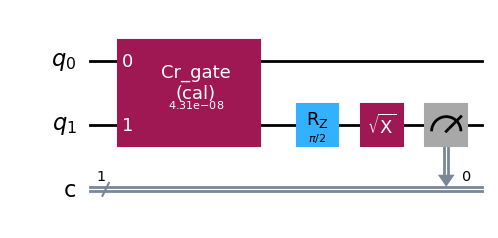

In [179]:
from qiskit import schedule
from qiskit.circuit import Gate
resonance_7 = 0.0025*9.1
cr_ham_experiment = CrossResonanceHamiltonian_angle(
    physical_qubits=(0, 1),
    durations=np.linspace(1e-7, 6e-7, 17),
    amp = 0.3,
    amp_t = 0.0004,
    c_angle = 0,
    x_angle = 1.57,
    backend=backend,
)

backend.target.update_from_instruction_schedule_map(cals.get_inst_map())
cr_ham_experiment.circuits()[0].draw("mpl")

In [180]:
%time data_cr = cr_ham_experiment.run().block_for_results()

CPU times: user 20.3 s, sys: 2.93 s, total: 23.2 s
Wall time: 20.1 s


In [181]:
854

854

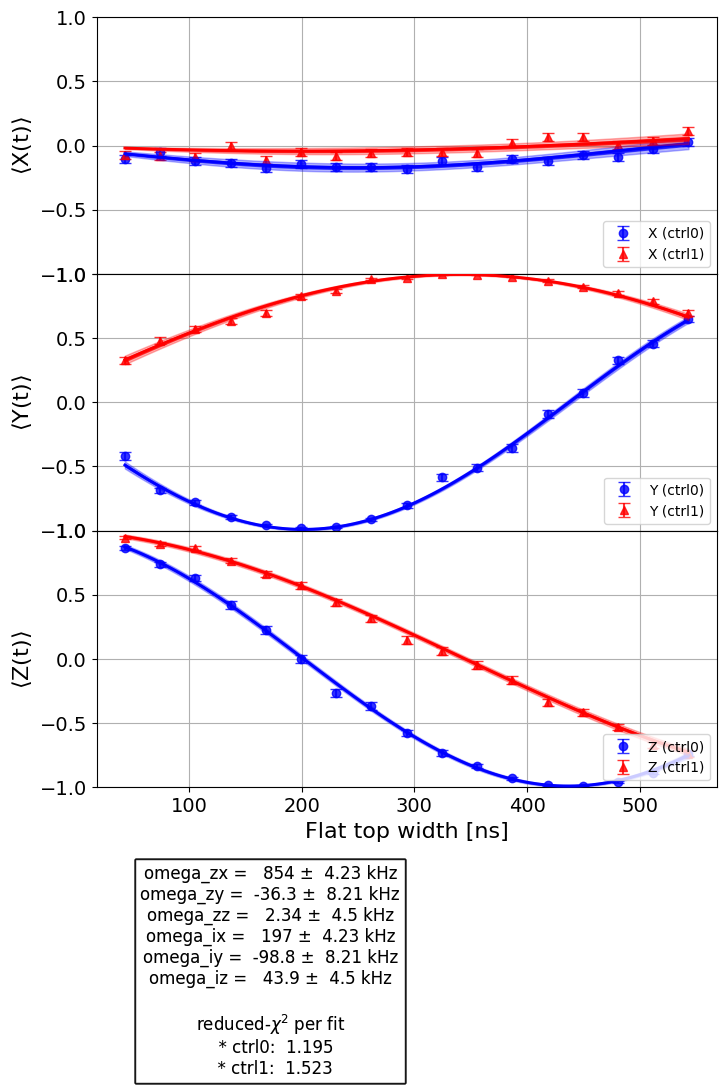

In [182]:
data_cr.figure(0)

In [159]:
6110/858

7.121212121212121

In [230]:
from qiskit import circuit
from qiskit import QuantumCircuit
class EchoedCrossResonanceHamiltonian_double(CrossResonanceHamiltonian_angle):
    r"""Echoed cross resonance Hamiltonian tomography experiment.

    # section: overview

        This is a variant of :class:`CrossResonanceHamiltonian`
        for which the experiment framework is identical but the
        cross resonance operation is realized as an echoed sequence
        to remove unwanted single qubit rotations. The cross resonance
        circuit looks like:

        .. parsed-literal::

                 ┌────────────────────┐  ┌───┐  ┌────────────────────┐
            q_0: ┤0                   ├──┤ X ├──┤0                   ├──────────
                 │  cr_tone(duration) │┌─┴───┴─┐│  cr_tone(duration) │┌────────┐
            q_1: ┤1                   ├┤ Rz(π) ├┤1                   ├┤ Rz(-π) ├
                 └────────────────────┘└───────┘└────────────────────┘└────────┘

        Here two ``cr_tone`` are applied, where the latter one is with the
        control qubit state flipped and with a phase flip of the target qubit frame.
        This operation is equivalent to applying the ``cr_tone`` with a negative amplitude.
        The Hamiltonian for this decomposition has no IX and ZI interactions,
        and also a reduced IY interaction to some extent (not completely eliminated) [1].
        Note that the CR Hamiltonian tomography experiment cannot detect the ZI term.
        However, it is sensitive to the IX and IY terms.

    # section: reference
        .. ref_arxiv:: 1 2007.02925

    """
    num_pulses = 4

    def _build_cr_circuit(self, pulse_gate: circuit.Gate) -> QuantumCircuit:
        """Single tone cross resonance.

        Args:
            pulse_gate: A pulse gate to represent a single cross resonance pulse.

        Returns:
            A circuit definition for the cross resonance pulse to measure.
        """
        ''' cr_circuit = QuantumCircuit(2)
        cr_circuit.append(pulse_gate, [0, 1])
        cr_circuit.x(0)
        cr_circuit.rz(np.pi, 1)
        cr_circuit.append(pulse_gate, [0, 1])
        cr_circuit.rz(-np.pi, 1)
        cr_circuit.x(0)



        cr_circuit.rz(np.pi, 1)
        cr_circuit.append(pulse_gate, [0, 1])
        cr_circuit.rz(-np.pi, 1)
        cr_circuit.x(0)
        cr_circuit.append(pulse_gate, [0, 1])
        cr_circuit.x(0) '''

        ## 다른 실험해볼거
        cr_circuit = QuantumCircuit(2)
        cr_circuit.append(pulse_gate, [0, 1])
        cr_circuit.rz(np.pi, 1)
        cr_circuit.append(pulse_gate, [0, 1])
        cr_circuit.rz(-np.pi, 1)


        cr_circuit.x(1)
        cr_circuit.x(0)
        cr_circuit.append(pulse_gate, [0, 1])
        cr_circuit.rz(-np.pi, 1)
        cr_circuit.append(pulse_gate, [0, 1])
        cr_circuit.rz(np.pi, 1)
        cr_circuit.x(0)
        cr_circuit.x(1)
        return cr_circuit


In [155]:
from qiskit import circuit
from qiskit import QuantumCircuit
class EchoedCrossResonanceHamiltonian(CrossResonanceHamiltonian_angle):
    r"""Echoed cross resonance Hamiltonian tomography experiment.

    # section: overview

        This is a variant of :class:`CrossResonanceHamiltonian`
        for which the experiment framework is identical but the
        cross resonance operation is realized as an echoed sequence
        to remove unwanted single qubit rotations. The cross resonance
        circuit looks like:

        .. parsed-literal::

                 ┌────────────────────┐  ┌───┐  ┌────────────────────┐
            q_0: ┤0                   ├──┤ X ├──┤0                   ├──────────
                 │  cr_tone(duration) │┌─┴───┴─┐│  cr_tone(duration) │┌────────┐
            q_1: ┤1                   ├┤ Rz(π) ├┤1                   ├┤ Rz(-π) ├
                 └────────────────────┘└───────┘└────────────────────┘└────────┘

        Here two ``cr_tone`` are applied, where the latter one is with the
        control qubit state flipped and with a phase flip of the target qubit frame.
        This operation is equivalent to applying the ``cr_tone`` with a negative amplitude.
        The Hamiltonian for this decomposition has no IX and ZI interactions,
        and also a reduced IY interaction to some extent (not completely eliminated) [1].
        Note that the CR Hamiltonian tomography experiment cannot detect the ZI term.
        However, it is sensitive to the IX and IY terms.

    # section: reference
        .. ref_arxiv:: 1 2007.02925

    """
    num_pulses = 2

    def _build_cr_circuit(self, pulse_gate: circuit.Gate) -> QuantumCircuit:
        """Single tone cross resonance.

        Args:
            pulse_gate: A pulse gate to represent a single cross resonance pulse.

        Returns:
            A circuit definition for the cross resonance pulse to measure.
        """
        cr_circuit = QuantumCircuit(2)
        cr_circuit.append(pulse_gate, [0, 1])
        cr_circuit.x(0)
        cr_circuit.rz(np.pi, 1)
        cr_circuit.append(pulse_gate, [0, 1])
        cr_circuit.rz(-np.pi, 1)

        return cr_circuit

In [189]:
import math

def angle_amp(real,imag):

  # 크기 계산
  amp = math.sqrt(real**2 + imag**2)

  # 각도 계산 (라디안 단위)
  angle = math.atan2(imag, real)
  return amp,angle

In [196]:
resonance_7

0.02275

In [195]:
angle_amp(resonance_7,0.0004)

(0.02275351621178582, 0.01758060610063206)

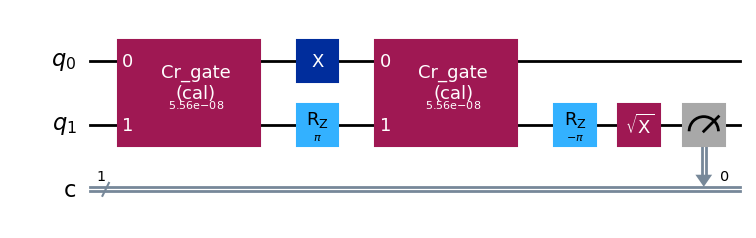

In [201]:
from qiskit_experiments.library import CrossResonanceHamiltonian
from qiskit.circuit import Gate
cr_ham_experiment = EchoedCrossResonanceHamiltonian(
    physical_qubits=(0, 1),
    durations=np.linspace(1e-7, 3e-7, 17),
    amp = 0.3,
    amp_t = 0.02275351621178582,
    backend=backend,
    c_angle = 0,
    x_angle = 0.01758060610063206,

)

backend.target.update_from_instruction_schedule_map(cals.get_inst_map())
cr_ham_experiment.circuits()[7].draw("mpl")

In [198]:
%time data_cr = cr_ham_experiment.run().block_for_results()

CPU times: user 23.5 s, sys: 2.91 s, total: 26.4 s
Wall time: 23.5 s


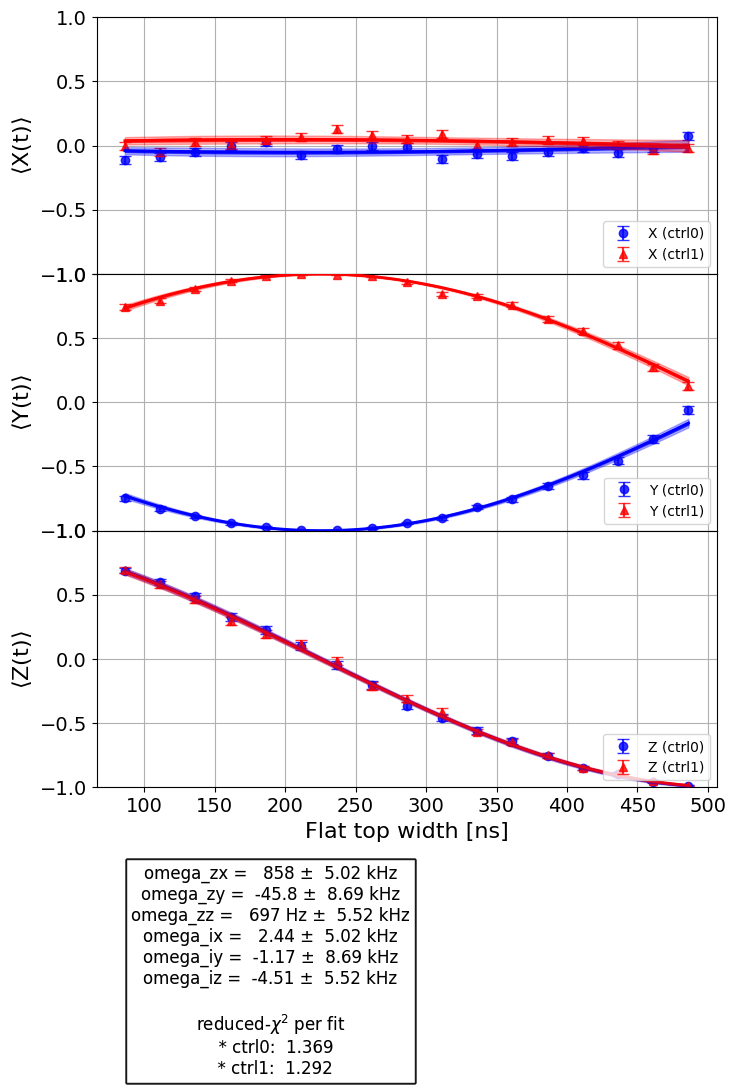

In [199]:
data_cr.figure(0)

In [248]:
angle_amp(resonance_7*8.5/7,0.0004)

(0.027627895775827735, 0.01447862620309404)

In [269]:
angle_amp(0.01,0.0004)

(0.010007996802557442, 0.039978687123290044)

In [258]:
import math

# 주어진 크기와 각도 (각도는 라디안 단위)
r = 5
theta = math.radians(53.13)  # 도 단위의 각도를 라디안으로 변환

# 실수항과 허수항 계산
real = r * math.cos(theta)
imag = r * math.sin(theta)

# 결과 출력
print(f"실수항 (real): {real}")
print(f"허수항 (imag): {imag}")

실수항 (real): 3.0000071456633126
허수항 (imag): 3.999994640742543


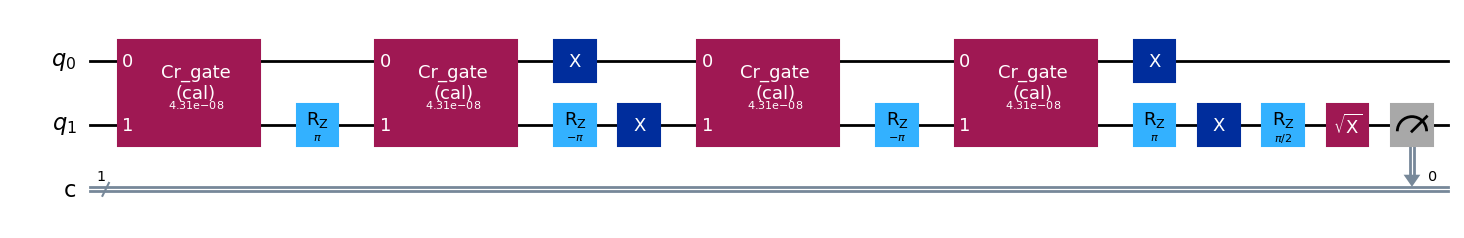

In [270]:
from qiskit_experiments.library import CrossResonanceHamiltonian
from qiskit.circuit import Gate
cr_ham_experiment = EchoedCrossResonanceHamiltonian_double(
    physical_qubits=(0, 1),
    durations=np.linspace(1e-7, 3.0e-7, 17),
    amp = 0.3,
    amp_t = 0.010007996802557442,
    backend=backend,
    x_angle=0.039978687123290044,
    c_angle=0

)

backend.target.update_from_instruction_schedule_map(cals.get_inst_map())
cr_ham_experiment.circuits()[0].draw("mpl")

In [271]:
%time data_cr = cr_ham_experiment.run().block_for_results()

CPU times: user 41.3 s, sys: 2.84 s, total: 44.1 s
Wall time: 45.2 s


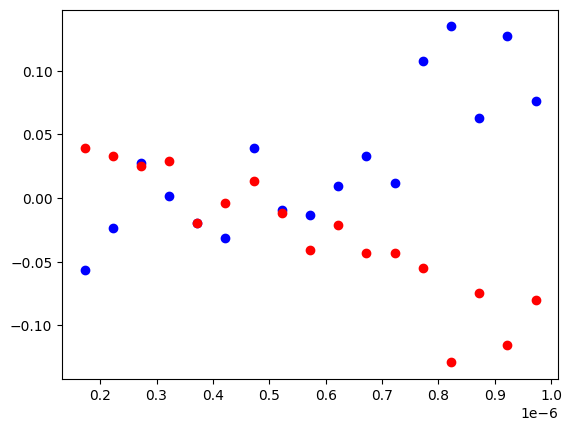

In [272]:
# 첫 번째 플롯
import matplotlib.pyplot as plt
x_list =[]
data_list_0 = []
data_list_1 = []

for data in data_cr.data():
  if data['metadata']['meas_basis'] == 'x':
    if data['metadata']['control_state'] == 0:
        x_list.append(data['metadata']['xval'])
        try:
          count_1 = data['counts']['1']
        except:
          count_1 =0
        data_list_0.append((data['counts']['0']-count_1)/(data['counts']['0']+count_1))
    else:
        try:
            count_1 = data['counts']['1']
        except:
          count_1 =0
        data_list_1.append((data['counts']['0']-count_1)/(data['counts']['0']+count_1))

plt.plot(x_list,data_list_0,'bo')
plt.plot(x_list,data_list_1,'ro')

#plt.ylim(,1)
plt.show() # 0.0025*9.1*2

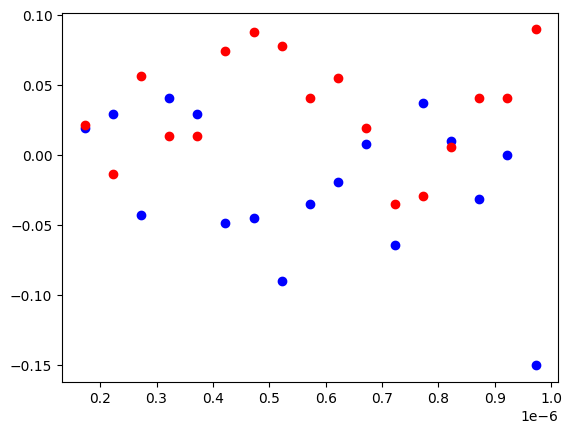

In [265]:
# 첫 번째 플롯 ##  완벽하게 fitting한 값
import matplotlib.pyplot as plt
x_list =[]
data_list_0 = []
data_list_1 = []

for data in data_cr.data():
  if data['metadata']['meas_basis'] == 'x':
    if data['metadata']['control_state'] == 0:
        x_list.append(data['metadata']['xval'])
        try:
          count_1 = data['counts']['1']
        except:
          count_1 =0
        data_list_0.append((data['counts']['0']-count_1)/(data['counts']['0']+count_1))
    else:
        try:
            count_1 = data['counts']['1']
        except:
          count_1 =0
        data_list_1.append((data['counts']['0']-count_1)/(data['counts']['0']+count_1))

plt.plot(x_list,data_list_0,'bo')
plt.plot(x_list,data_list_1,'ro')
#plt.ylim(0.99,1)
plt.show() # 0.0025*9.1*2

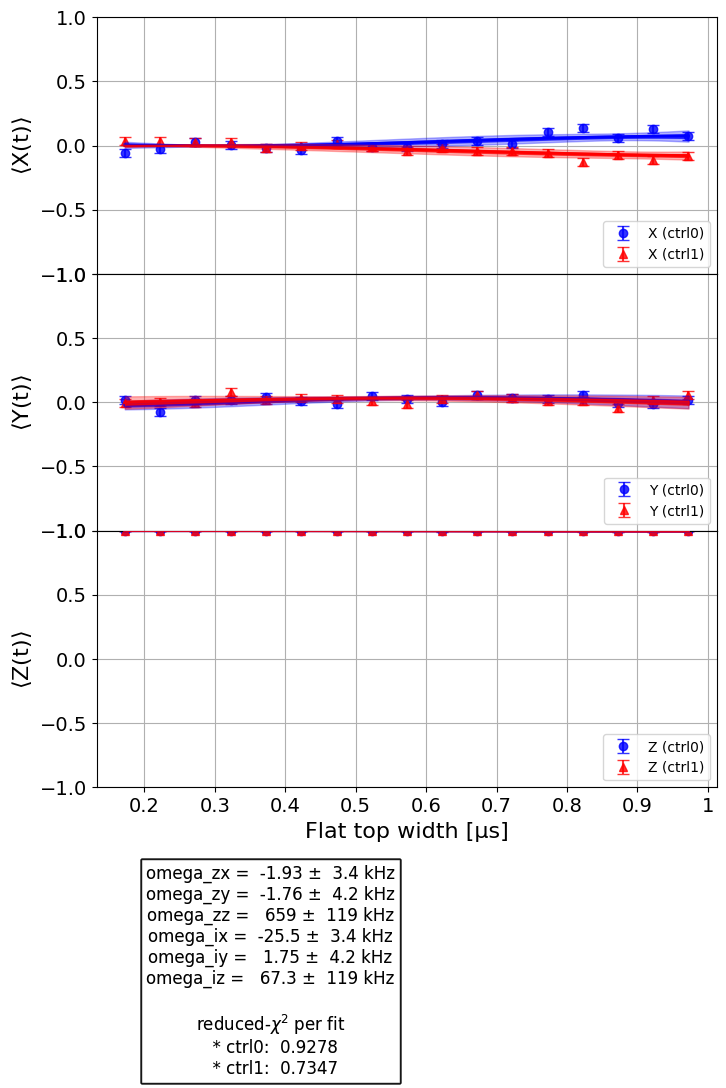

In [273]:
data_cr.figure(0)

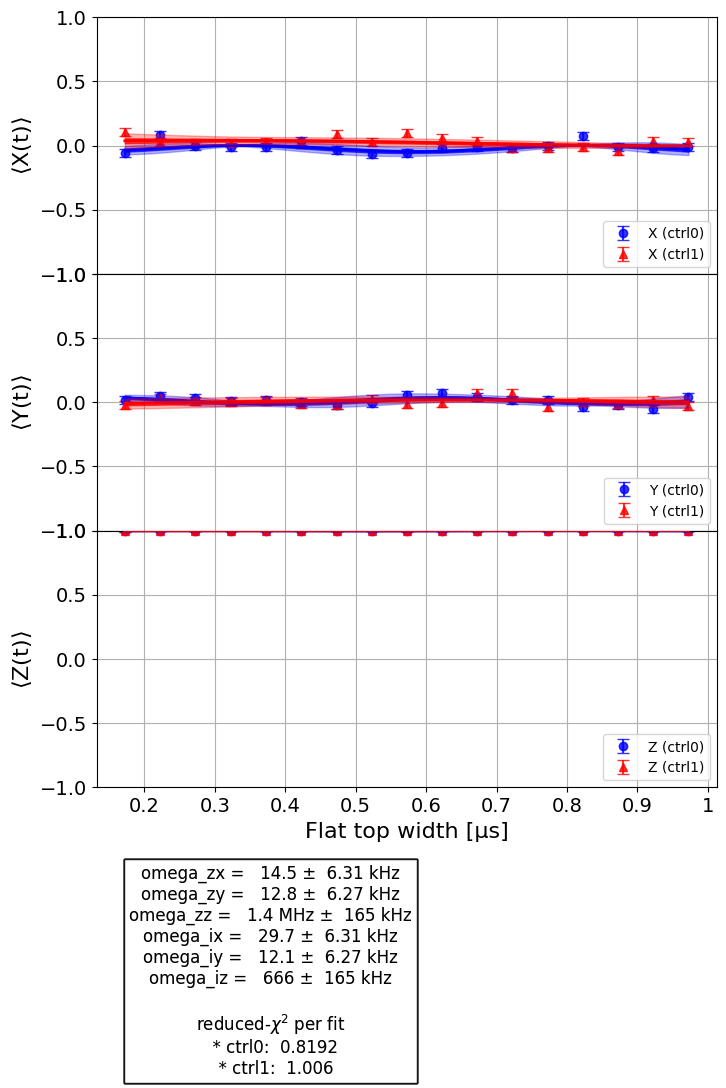

In [256]:
data_cr.figure(0)